## Objectives

This notebook identifies unusual sales patterns using statistical and machine learning techniques.

The following anomaly detection methods are implemented:

- Z-Score Analysis
- Interquartile Range (IQR)
- Isolation Forest

The detected anomalies will help identify unexpected demand spikes, stock shortages, promotional events, or operational issues.

In [68]:
import sys
import os

project_root = r"C:\Users\Jainam\OneDrive\Documents\Infotact Solutions\Project 2"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [70]:
from src.anomaly_detection import (
    detect_zscore,
    detect_iqr,
    detect_isolation_forest
)

In [71]:
import os
import pandas as pd

csv_path = os.path.join(
    r"C:\Users\Jainam\OneDrive\Documents\Infotact Solutions\Project 2",
    "data",
    "processed",
    "clean_sales.csv"
)

df = pd.read_csv(
    csv_path,
    parse_dates=["date"],
    index_col="date"
)

df.head()

,store_id,item_id,sales,price,promo,weekday,month
date,,,,,,,
2019-01-01,store_1,item_1,41,21.30,0,1,1
2019-01-02,store_1,item_1,53,21.30,0,2,1
2019-01-03,store_1,item_1,39,21.30,0,3,1
2019-01-04,store_1,item_1,35,21.30,0,4,1
2019-01-05,store_1,item_1,51,17.04,1,5,1


In [72]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2019-01-01 to 2023-12-31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   store_id  1826 non-null   str    
 1   item_id   1826 non-null   str    
 2   sales     1826 non-null   int64  
 3   price     1826 non-null   float64
 4   promo     1826 non-null   int64  
 5   weekday   1826 non-null   int64  
 6   month     1826 non-null   int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 137.3 KB


In [73]:
df.describe()

,sales,price,promo,weekday,month
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,44.780942,20.870734,0.100767,3.001643,6.523549
std,13.761220,1.282695,0.301102,1.999862,3.449478
min,16.000000,17.040000,0.000000,0.000000,1.000000
25%,35.000000,21.300000,0.000000,1.000000,4.000000
50%,43.000000,21.300000,0.000000,3.000000,7.000000
75%,53.000000,21.300000,0.000000,5.000000,10.000000
max,107.000000,21.300000,1.000000,6.000000,12.000000


In [74]:
df.isnull().sum()

store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [75]:
df.duplicated().sum()

np.int64(635)

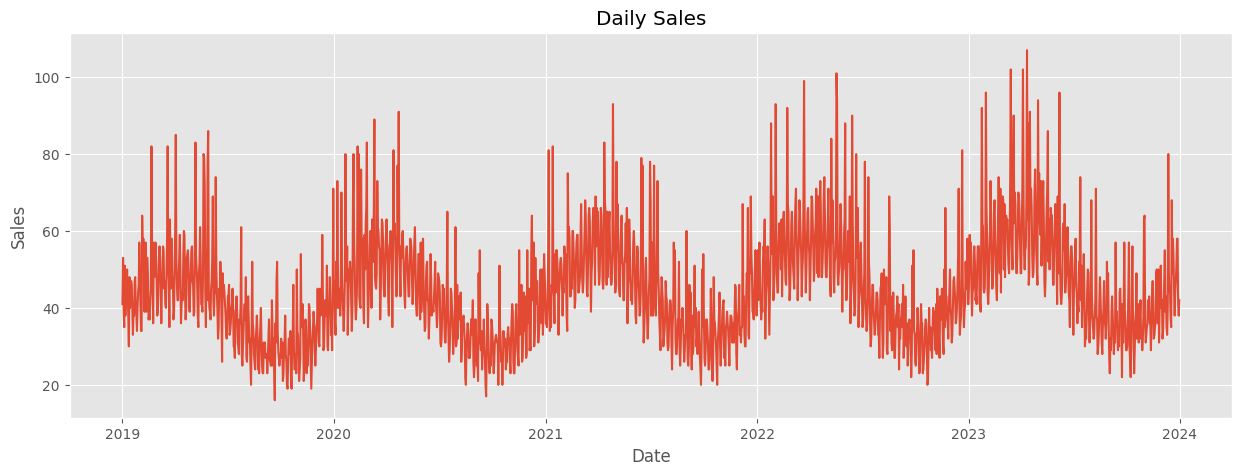

In [76]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["sales"])

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [77]:
df = detect_zscore(df)

In [78]:
df[["sales","z_score","z_anomaly"]].head()

,sales,z_score,z_anomaly
date,,,
2019-01-01,41,-0.274829,False
2019-01-02,53,0.597426,False
2019-01-03,39,-0.420204,False
2019-01-04,35,-0.710956,False
2019-01-05,51,0.452050,False


In [79]:
print("Total Z-Score Anomalies:", df["z_anomaly"].sum())

Total Z-Score Anomalies: 21


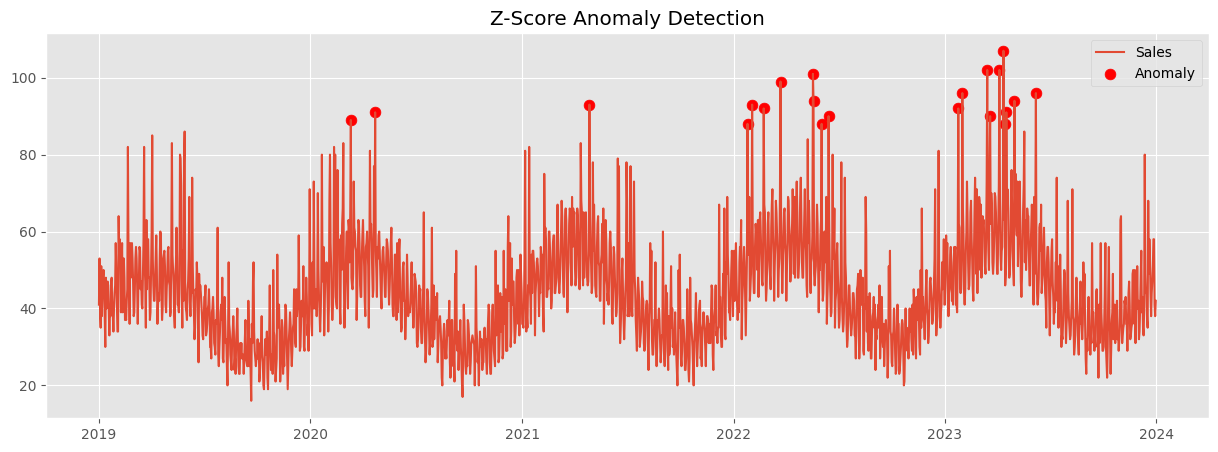

In [80]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["sales"],
    label="Sales"
)

plt.scatter(
    df[df["z_anomaly"]].index,
    df[df["z_anomaly"]]["sales"],
    color="red",
    s=60,
    label="Anomaly"
)

plt.legend()

plt.title("Z-Score Anomaly Detection")

plt.show()

In [81]:
df = detect_iqr(df)

In [82]:
df[["sales","iqr_anomaly"]].head()

,sales,iqr_anomaly
date,,
2019-01-01,41,False
2019-01-02,53,False
2019-01-03,39,False
2019-01-04,35,False
2019-01-05,51,False


In [83]:
print("Total IQR Anomalies:", df["iqr_anomaly"].sum())

Total IQR Anomalies: 35


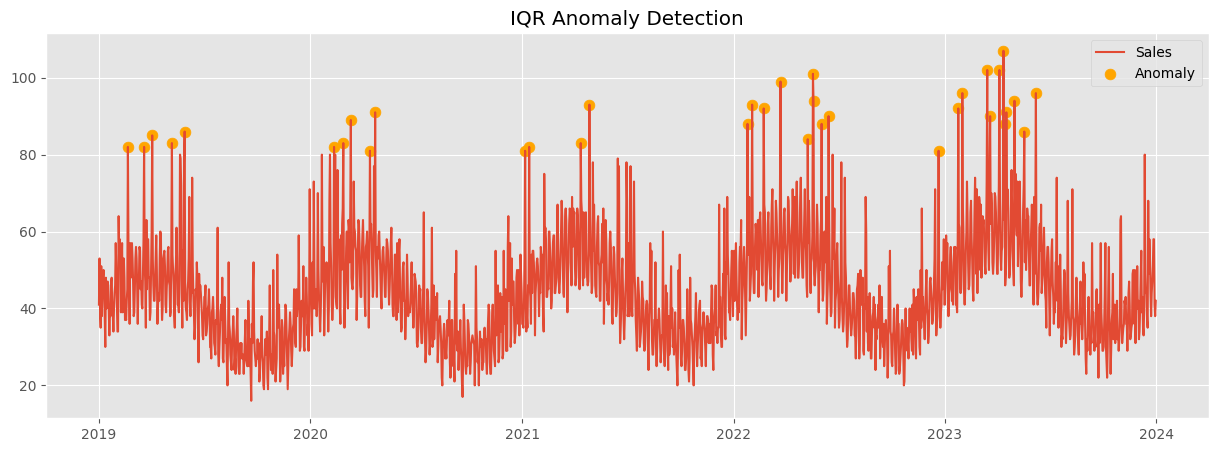

In [84]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["sales"],
    label="Sales"
)

plt.scatter(
    df[df["iqr_anomaly"]].index,
    df[df["iqr_anomaly"]]["sales"],
    color="orange",
    s=60,
    label="Anomaly"
)

plt.legend()

plt.title("IQR Anomaly Detection")

plt.show()

In [85]:
df = detect_isolation_forest(df)

In [86]:
df[["sales","iforest","iforest_anomaly"]].head()

,sales,iforest,iforest_anomaly
date,,,
2019-01-01,41,1,False
2019-01-02,53,1,False
2019-01-03,39,1,False
2019-01-04,35,1,False
2019-01-05,51,1,False


In [87]:
print("Total Isolation Forest Anomalies:", df["iforest_anomaly"].sum())

Total Isolation Forest Anomalies: 19


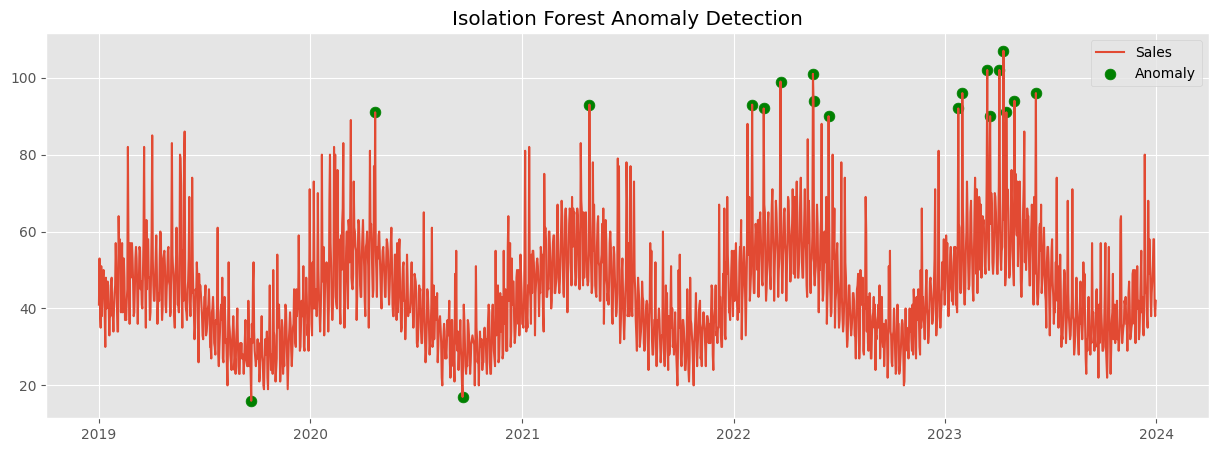

In [88]:
plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["sales"],
    label="Sales"
)

plt.scatter(
    df[df["iforest_anomaly"]].index,
    df[df["iforest_anomaly"]]["sales"],
    color="green",
    s=60,
    label="Anomaly"
)

plt.legend()

plt.title("Isolation Forest Anomaly Detection")

plt.show()

In [89]:
comparison = pd.DataFrame({

    "Method":[
        "Z-Score",
        "IQR",
        "Isolation Forest"
    ],

    "Detected Anomalies":[

        df["z_anomaly"].sum(),

        df["iqr_anomaly"].sum(),

        df["iforest_anomaly"].sum()

    ]

})

comparison

,Method,Detected Anomalies
0,Z-Score,21
1,IQR,35
2,Isolation Forest,19


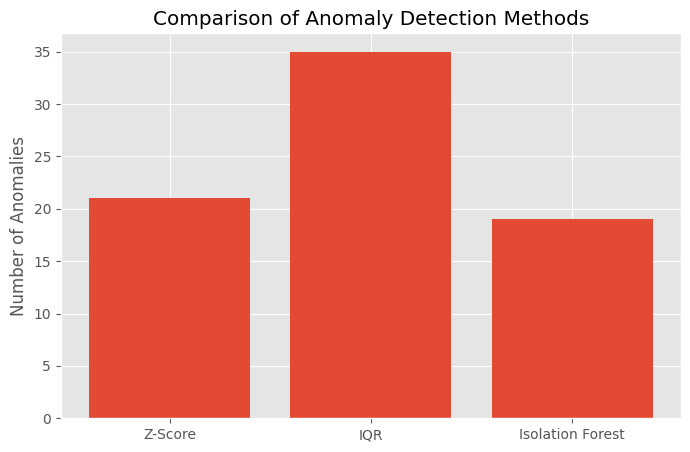

In [90]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison["Method"],

    comparison["Detected Anomalies"]

)

plt.title("Comparison of Anomaly Detection Methods")

plt.ylabel("Number of Anomalies")

plt.show()

In [91]:
df[
    df["iforest_anomaly"]
].head(10)

,store_id,item_id,sales,price,promo,weekday,month,z_score,z_anomaly,iqr_anomaly,iforest,iforest_anomaly
date,,,,,,,,,,,,
2019-09-21,store_1,item_1,16,21.30,0,5,9,-2.092026,False,False,-1,True
2020-04-22,store_1,item_1,91,17.04,1,2,4,3.359566,True,True,-1,True
2020-09-20,store_1,item_1,17,21.30,0,6,9,-2.019338,False,False,-1,True
2021-04-27,store_1,item_1,93,17.04,1,1,4,3.504941,True,True,-1,True
2022-02-02,store_1,item_1,93,17.04,1,2,2,3.504941,True,True,-1,True
2022-02-22,store_1,item_1,92,17.04,1,1,2,3.432253,True,True,-1,True
2022-03-23,store_1,item_1,99,17.04,1,2,3,3.941069,True,True,-1,True
2022-05-18,store_1,item_1,101,17.04,1,2,5,4.086444,True,True,-1,True
2022-05-19,store_1,item_1,94,17.04,1,3,5,3.577629,True,True,-1,True


In [92]:
from pathlib import Path

project_root = Path(r"C:\Users\Jainam\OneDrive\Documents\Infotact Solutions\Project 2")

output_path = project_root / "data" / "processed" / "anomaly_detection.csv"

df.to_csv(output_path, index=False)

# Conclusion

Three anomaly detection techniques were successfully applied to the cleaned supply chain dataset.

### Key Findings

- **Z-Score** identified observations that deviated significantly from the mean.
- **IQR** detected extreme values using quartile-based statistics.
- **Isolation Forest** identified complex anomalies using an unsupervised machine learning algorithm.

### Business Value

The detected anomalies may indicate:

- Unexpected spikes in product demand
- Inventory shortages
- Promotional campaigns
- Seasonal events
- Data quality issues
- Operational disruptions

These insights help supply chain managers investigate unusual events and improve inventory planning.